In [1]:

import numpy as np
import pandas as pd
import pickle
from scipy import stats
import matplotlib.pyplot as plt

# Load the N=10^7 results
df_n7 = pd.read_csv('N10^7_detailed_results.csv')
print("N=10^7 results loaded:")
print(df_n7.head(20))
print("\nColumns:", df_n7.columns.tolist())
print("\nData shape:", df_n7.shape)


N=10^7 results loaded:
 Function N t_value peak_height r_value
0 Zeta 10000000 1.848485e+07 16.508561 0.780727
1 Zeta 10000000 1.232323e+07 10.284027 0.631713
2 Zeta 10000000 1.090909e+07 6.367052 -0.074793
3 Zeta 10000000 1.616162e+07 5.935386 1.437305
4 Zeta 10000000 1.191919e+07 5.878669 0.669312
5 Liouville 10000000 1.979798e+07 21.827989 1.924900
6 Liouville 10000000 1.787879e+07 17.305548 1.181383
7 Liouville 10000000 1.363636e+07 12.219003 1.787888
8 Liouville 10000000 1.929293e+07 9.473383 -0.345984
9 Liouville 10000000 1.212121e+07 7.941801 0.850410

Columns: ['Function', 'N', 't_value', 'peak_height', 'r_value']

Data shape: (10, 5)


In [2]:

# Extract zeta function peaks from N=10^7
zeta_n7_peaks = df_n7[df_n7['Function'] == 'Zeta']['t_value'].values
print("Zeta function peaks at N=10^7:")
print(zeta_n7_peaks)
print(f"\nNumber of peaks: {len(zeta_n7_peaks)}")


Zeta function peaks at N=10^7:
[18484848.48484848 12323232.32323232 10909090.90909091 16161616.16161616
 11919191.91919192]

Number of peaks: 5


In [3]:

# Load the N=10^6 results
with open('detailed_results_N1e6.pkl', 'rb') as f:
 results_n6 = pickle.load(f)

print("N=10^6 results loaded. Keys:")
print(results_n6.keys())


N=10^6 results loaded. Keys:
dict_keys(['zeta', 'f_rand', 'L_mobius'])


In [4]:

# Explore the structure of the zeta results
print("Zeta function results at N=10^6:")
print("Keys:", results_n6['zeta'].keys())
print("\nPeak locations shape:", results_n6['zeta']['peak_locs'].shape)
print("Peak locations (top 5):", results_n6['zeta']['peak_locs'][:5])
print("\nPeak heights (top 5):", results_n6['zeta']['peak_heights'][:5])
print("\nr_values shape:", results_n6['zeta']['r_values'].shape)
print("r_values (top 5):", results_n6['zeta']['r_values'][:5])


Zeta function results at N=10^6:
Keys: dict_keys(['magnitudes', 'peak_t', 'peak_heights', 'peak_indices', 'r_values', 'mean_r', 'std_r', 'median_r'])


KeyError: 'peak_locs'

In [5]:

# Use the correct key name - 'peak_t' instead of 'peak_locs'
print("Zeta function results at N=10^6:")
print("Keys:", results_n6['zeta'].keys())
print("\nPeak t values shape:", results_n6['zeta']['peak_t'].shape)
print("Peak t values (top 5):", results_n6['zeta']['peak_t'][:5])
print("\nPeak heights (top 5):", results_n6['zeta']['peak_heights'][:5])
print("\nr_values shape:", results_n6['zeta']['r_values'].shape)
print("r_values (top 5):", results_n6['zeta']['r_values'][:5])

# Store for later use
zeta_n6_peaks = results_n6['zeta']['peak_t'][:5]
print(f"\n\nTop 5 zeta peaks at N=10^6: {zeta_n6_peaks}")


Zeta function results at N=10^6:
Keys: dict_keys(['magnitudes', 'peak_t', 'peak_heights', 'peak_indices', 'r_values', 'mean_r', 'std_r', 'median_r'])

Peak t values shape: (50,)
Peak t values (top 5): [1948000. 1828000. 1894000. 1734000. 1787000.]

Peak heights (top 5): [20.26291779 17.54511647 16.4788541 16.45057992 15.93424324]

r_values shape: (50,)
r_values (top 5): [3.53246643 3.93381778 1.54153057 0.69932041 2.7271974 ]


Top 5 zeta peaks at N=10^6: [1948000. 1828000. 1894000. 1734000. 1787000.]


In [6]:

# Load omega values for both N
with open('omega_values_N1e6.pkl', 'rb') as f:
 omega_n6 = pickle.load(f)

with open('omega_values_N1e7.pkl', 'rb') as f:
 omega_n7 = pickle.load(f)

print(f"Omega values N=10^6: shape {omega_n6.shape}, dtype {omega_n6.dtype}")
print(f"Omega values N=10^7: shape {omega_n7.shape}, dtype {omega_n7.dtype}")
print(f"\nFirst 10 omega values (N=10^6): {omega_n6[:10]}")
print(f"First 10 omega values (N=10^7): {omega_n7[:10]}")


Omega values N=10^6: shape (1000000,), dtype int64
Omega values N=10^7: shape (10000000,), dtype int32

First 10 omega values (N=10^6): [0 1 1 2 1 2 1 3 2 2]
First 10 omega values (N=10^7): [0 1 1 2 1 2 1 3 2 2]


In [7]:

def compute_dirichlet_polynomial_zeta(t, N, omega_values):
 """
 Compute the Dirichlet polynomial for the zeta function at t.
 Uses Kahan compensated summation for high precision.
 D_zeta(t; N) = Σ_{n=1}^N 1/n^{1/2+it}
 """
 n = np.arange(1, N+1)
 exponent = -(0.5 + 1j*t) * np.log(n)
 
 # Kahan compensated summation
 summation = 0.0 + 0.0j
 compensation = 0.0 + 0.0j
 
 for val in np.exp(exponent):
 y = val - compensation
 temp = summation + y
 compensation = (temp - summation) - y
 summation = temp
 
 return summation

def compute_omega_class_sums(t, N, omega_values):
 """
 Compute S_k = Σ_{n: Ω(n)=k} a_n/n^{1/2+it} for zeta function.
 For zeta, a_n = 1 for all n.
 Uses Kahan compensated summation.
 """
 n = np.arange(1, N+1)
 exponent = -(0.5 + 1j*t) * np.log(n)
 terms = np.exp(exponent)
 
 # Get max omega class
 max_omega = int(omega_values[:N].max())
 
 # Compute S_k for each omega class using Kahan summation
 S_k = {}
 for k in range(max_omega + 1):
 mask = (omega_values[:N] == k)
 if np.any(mask):
 summation = 0.0 + 0.0j
 compensation = 0.0 + 0.0j
 
 for val in terms[mask]:
 y = val - compensation
 temp = summation + y
 compensation = (temp - summation) - y
 summation = temp
 
 S_k[k] = summation
 else:
 S_k[k] = 0.0 + 0.0j
 
 return S_k

# Test with one peak from N=10^6
print("Testing computation with first N=10^6 peak...")
t_test = zeta_n6_peaks[0]
S_k_test = compute_omega_class_sums(t_test, 10**6, omega_n6)
print(f"\nAt t={t_test}, N=10^6:")
print(f"Number of omega classes: {len(S_k_test)}")
print(f"First few S_k values:")
for k in range(min(6, len(S_k_test))):
 print(f" S_{k} = {S_k_test[k]:.6f}, |S_{k}| = {abs(S_k_test[k]):.6f}")


Testing computation with first N=10^6 peak...



At t=1948000.0, N=10^6:
Number of omega classes: 20
First few S_k values:
 S_0 = 1.000000+0.000000j, |S_0| = 1.000000
 S_1 = 2.449656+0.091917j, |S_1| = 2.451380
 S_2 = 4.170005-0.664706j, |S_2| = 4.222651
 S_3 = 4.600310-1.675735j, |S_3| = 4.896013
 S_4 = 3.744668-2.421807j, |S_4| = 4.459561
 S_5 = 1.950670-2.349391j, |S_5| = 3.053645


In [8]:

def analyze_power_distribution(S_k):
 """
 Analyze the power distribution across omega classes.
 Returns:
 - P_k: dictionary of power values
 - total_power: sum of all powers
 - frac_high_k: fraction of power in k >= 4
 - entropy: Shannon entropy of normalized power distribution
 """
 # Compute power for each class
 P_k = {k: abs(S_k[k])**2 for k in S_k}
 
 # Total power
 total_power = sum(P_k.values())
 
 # Fraction of power in k >= 4
 power_high_k = sum(P_k[k] for k in P_k if k >= 4)
 frac_high_k = power_high_k / total_power if total_power > 0 else 0
 
 # Shannon entropy
 # H = -Σ p_k log(p_k) where p_k = P_k / total_power
 entropy = 0.0
 for k in P_k:
 if P_k[k] > 0:
 p_k = P_k[k] / total_power
 entropy -= p_k * np.log(p_k)
 
 return P_k, total_power, frac_high_k, entropy

# Test the power distribution analysis
P_k_test, total_power_test, frac_high_k_test, entropy_test = analyze_power_distribution(S_k_test)

print(f"Power distribution analysis for test peak:")
print(f"Total power: {total_power_test:.6f}")
print(f"Fraction in k >= 4: {frac_high_k_test:.6f}")
print(f"Shannon entropy: {entropy_test:.6f}")
print(f"\nPower by omega class:")
for k in range(min(10, len(P_k_test))):
 frac = P_k_test[k] / total_power_test
 print(f" k={k}: P_k = {P_k_test[k]:.6f}, fraction = {frac:.6f}")


Power distribution analysis for test peak:
Total power: 84.145599
Fraction in k >= 4: 0.419922
Shannon entropy: 1.778676

Power by omega class:
 k=0: P_k = 1.000000, fraction = 0.011884
 k=1: P_k = 6.009262, fraction = 0.071415
 k=2: P_k = 17.830780, fraction = 0.211904
 k=3: P_k = 23.970939, fraction = 0.284875
 k=4: P_k = 19.887687, fraction = 0.236349
 k=5: P_k = 9.324750, fraction = 0.110817
 k=6: P_k = 3.866701, fraction = 0.045953
 k=7: P_k = 1.460885, fraction = 0.017361
 k=8: P_k = 0.511576, fraction = 0.006080
 k=9: P_k = 0.149435, fraction = 0.001776


In [9]:

# Now compute power distribution for all 5 peaks at N=10^6
print("Computing power distributions for N=10^6 zeta peaks...")
print("=" * 70)

results_n6_analysis = []

for i, t_peak in enumerate(zeta_n6_peaks):
 print(f"\nPeak {i+1}: t = {t_peak}")
 S_k = compute_omega_class_sums(t_peak, 10**6, omega_n6)
 P_k, total_power, frac_high_k, entropy = analyze_power_distribution(S_k)
 
 results_n6_analysis.append({
 't': t_peak,
 'total_power': total_power,
 'frac_high_k': frac_high_k,
 'entropy': entropy,
 'P_k': P_k
 })
 
 print(f" Total power: {total_power:.6f}")
 print(f" Fraction in k >= 4: {frac_high_k:.6f}")
 print(f" Shannon entropy: {entropy:.6f}")

print("\n" + "=" * 70)
print("Summary for N=10^6:")
frac_high_k_n6 = [r['frac_high_k'] for r in results_n6_analysis]
entropy_n6 = [r['entropy'] for r in results_n6_analysis]
print(f"Mean fraction in k >= 4: {np.mean(frac_high_k_n6):.6f} ± {np.std(frac_high_k_n6, ddof=1):.6f}")
print(f"Mean Shannon entropy: {np.mean(entropy_n6):.6f} ± {np.std(entropy_n6, ddof=1):.6f}")


Computing power distributions for N=10^6 zeta peaks...

Peak 1: t = 1948000.0


 Total power: 84.145599
 Fraction in k >= 4: 0.419922
 Shannon entropy: 1.778676

Peak 2: t = 1828000.0


 Total power: 56.617908
 Fraction in k >= 4: 0.272695
 Shannon entropy: 1.666047

Peak 3: t = 1894000.0


 Total power: 107.468879
 Fraction in k >= 4: 0.266965
 Shannon entropy: 1.588005

Peak 4: t = 1734000.0


 Total power: 169.655788
 Fraction in k >= 4: 0.510645
 Shannon entropy: 1.876256

Peak 5: t = 1787000.0


 Total power: 61.738243
 Fraction in k >= 4: 0.186506
 Shannon entropy: 1.491701

Summary for N=10^6:
Mean fraction in k >= 4: 0.331347 ± 0.130917
Mean Shannon entropy: 1.680137 ± 0.151960


In [10]:

# Now compute power distributions for all 5 peaks at N=10^7
print("Computing power distributions for N=10^7 zeta peaks...")
print("=" * 70)

results_n7_analysis = []

for i, t_peak in enumerate(zeta_n7_peaks):
 print(f"\nPeak {i+1}: t = {t_peak}")
 S_k = compute_omega_class_sums(t_peak, 10**7, omega_n7)
 P_k, total_power, frac_high_k, entropy = analyze_power_distribution(S_k)
 
 results_n7_analysis.append({
 't': t_peak,
 'total_power': total_power,
 'frac_high_k': frac_high_k,
 'entropy': entropy,
 'P_k': P_k
 })
 
 print(f" Total power: {total_power:.6f}")
 print(f" Fraction in k >= 4: {frac_high_k:.6f}")
 print(f" Shannon entropy: {entropy:.6f}")

print("\n" + "=" * 70)
print("Summary for N=10^7:")
frac_high_k_n7 = [r['frac_high_k'] for r in results_n7_analysis]
entropy_n7 = [r['entropy'] for r in results_n7_analysis]
print(f"Mean fraction in k >= 4: {np.mean(frac_high_k_n7):.6f} ± {np.std(frac_high_k_n7, ddof=1):.6f}")
print(f"Mean Shannon entropy: {np.mean(entropy_n7):.6f} ± {np.std(entropy_n7, ddof=1):.6f}")


Computing power distributions for N=10^7 zeta peaks...

Peak 1: t = 18484848.484848484


 Total power: 155.790846
 Fraction in k >= 4: 0.415483
 Shannon entropy: 1.636697

Peak 2: t = 12323232.323232325


 Total power: 53.241562
 Fraction in k >= 4: 0.373106
 Shannon entropy: 1.850290

Peak 3: t = 10909090.909090908


 Total power: 43.205637
 Fraction in k >= 4: 0.255651
 Shannon entropy: 1.812518

Peak 4: t = 16161616.16161616


 Total power: 9.074252
 Fraction in k >= 4: 0.210326
 Shannon entropy: 1.823331

Peak 5: t = 11919191.91919192


 Total power: 6.137516
 Fraction in k >= 4: 0.137237
 Shannon entropy: 1.683331

Summary for N=10^7:
Mean fraction in k >= 4: 0.278361 ± 0.114934
Mean Shannon entropy: 1.761234 ± 0.094862


In [11]:

# Statistical comparison between N=10^6 and N=10^7
print("STATISTICAL COMPARISON: N=10^6 vs N=10^7")
print("=" * 70)

# Fraction in k >= 4
print("\n1. Fraction of power in high omega classes (k >= 4):")
print(f" N=10^6: {np.mean(frac_high_k_n6):.6f} ± {np.std(frac_high_k_n6, ddof=1):.6f}")
print(f" N=10^7: {np.mean(frac_high_k_n7):.6f} ± {np.std(frac_high_k_n7, ddof=1):.6f}")
print(f" Change: {np.mean(frac_high_k_n7) - np.mean(frac_high_k_n6):.6f} ({(np.mean(frac_high_k_n7)/np.mean(frac_high_k_n6) - 1)*100:.2f}%)")

# Two-sample t-test
t_stat_frac, p_val_frac = stats.ttest_ind(frac_high_k_n6, frac_high_k_n7)
print(f"\n Two-sample t-test:")
print(f" t-statistic: {t_stat_frac:.4f}")
print(f" p-value: {p_val_frac:.4f}")
print(f" Significant at α=0.05: {p_val_frac < 0.05}")

# Shannon entropy
print("\n2. Shannon entropy of power distribution:")
print(f" N=10^6: {np.mean(entropy_n6):.6f} ± {np.std(entropy_n6, ddof=1):.6f}")
print(f" N=10^7: {np.mean(entropy_n7):.6f} ± {np.std(entropy_n7, ddof=1):.6f}")
print(f" Change: {np.mean(entropy_n7) - np.mean(entropy_n6):.6f} ({(np.mean(entropy_n7)/np.mean(entropy_n6) - 1)*100:.2f}%)")

# Two-sample t-test
t_stat_ent, p_val_ent = stats.ttest_ind(entropy_n6, entropy_n7)
print(f"\n Two-sample t-test:")
print(f" t-statistic: {t_stat_ent:.4f}")
print(f" p-value: {p_val_ent:.4f}")
print(f" Significant at α=0.05: {p_val_ent < 0.05}")

print("\n" + "=" * 70)


STATISTICAL COMPARISON: N=10^6 vs N=10^7

1. Fraction of power in high omega classes (k >= 4):
 N=10^6: 0.331347 ± 0.130917
 N=10^7: 0.278361 ± 0.114934
 Change: -0.052986 (-15.99%)

 Two-sample t-test:
 t-statistic: 0.6801
 p-value: 0.5156
 Significant at α=0.05: False

2. Shannon entropy of power distribution:
 N=10^6: 1.680137 ± 0.151960
 N=10^7: 1.761234 ± 0.094862
 Change: 0.081096 (4.83%)

 Two-sample t-test:
 t-statistic: -1.0123
 p-value: 0.3410
 Significant at α=0.05: False



In [12]:

# Let's also look at the detailed power distribution for each omega class
print("DETAILED POWER DISTRIBUTION ANALYSIS")
print("=" * 70)

# First, let's see the average power fraction per omega class for N=10^6
print("\nN=10^6 - Average power fraction by omega class:")
max_k_n6 = max(max(r['P_k'].keys()) for r in results_n6_analysis)
for k in range(max_k_n6 + 1):
 fracs = []
 for r in results_n6_analysis:
 if k in r['P_k']:
 fracs.append(r['P_k'][k] / r['total_power'])
 else:
 fracs.append(0.0)
 mean_frac = np.mean(fracs)
 std_frac = np.std(fracs, ddof=1)
 print(f" k={k:2d}: {mean_frac:.6f} ± {std_frac:.6f}")

print("\nN=10^7 - Average power fraction by omega class:")
max_k_n7 = max(max(r['P_k'].keys()) for r in results_n7_analysis)
for k in range(max_k_n7 + 1):
 fracs = []
 for r in results_n7_analysis:
 if k in r['P_k']:
 fracs.append(r['P_k'][k] / r['total_power'])
 else:
 fracs.append(0.0)
 mean_frac = np.mean(fracs)
 std_frac = np.std(fracs, ddof=1)
 print(f" k={k:2d}: {mean_frac:.6f} ± {std_frac:.6f}")


DETAILED POWER DISTRIBUTION ANALYSIS

N=10^6 - Average power fraction by omega class:
 k= 0: 0.012189 ± 0.004849
 k= 1: 0.097938 ± 0.029526
 k= 2: 0.267718 ± 0.078697
 k= 3: 0.290808 ± 0.032277
 k= 4: 0.196391 ± 0.034779
 k= 5: 0.081993 ± 0.052558
 k= 6: 0.033129 ± 0.028519
 k= 7: 0.012882 ± 0.012345
 k= 8: 0.004157 ± 0.004588
 k= 9: 0.001567 ± 0.001181
 k=10: 0.000752 ± 0.000418
 k=11: 0.000286 ± 0.000224
 k=12: 0.000121 ± 0.000084
 k=13: 0.000045 ± 0.000032
 k=14: 0.000015 ± 0.000010
 k=15: 0.000006 ± 0.000002
 k=16: 0.000003 ± 0.000002
 k=17: 0.000001 ± 0.000001
 k=18: 0.000000 ± 0.000000
 k=19: 0.000000 ± 0.000000

N=10^7 - Average power fraction by omega class:
 k= 0: 0.064296 ± 0.068832
 k= 1: 0.186426 ± 0.119531
 k= 2: 0.231378 ± 0.050954
 k= 3: 0.239540 ± 0.064698
 k= 4: 0.146856 ± 0.069393
 k= 5: 0.077477 ± 0.044642
 k= 6: 0.035781 ± 0.016092
 k= 7: 0.010994 ± 0.008520
 k= 8: 0.004288 ± 0.004713
 k= 9: 0.001890 ± 0.002103
 k=10: 0.000548 ± 0.000599
 k=11: 0.000202 ± 0.000221
 

In [13]:

# Compare power fractions in different omega class ranges
print("\nPOWER FRACTION COMPARISON BY OMEGA CLASS RANGES")
print("=" * 70)

def compute_power_ranges(results):
 """Compute power fractions in different omega class ranges"""
 k_0_1 = [] # k = 0, 1
 k_2_3 = [] # k = 2, 3
 k_4_plus = [] # k >= 4
 
 for r in results:
 total = r['total_power']
 
 # k = 0, 1
 power_0_1 = sum(r['P_k'].get(k, 0) for k in [0, 1])
 k_0_1.append(power_0_1 / total)
 
 # k = 2, 3
 power_2_3 = sum(r['P_k'].get(k, 0) for k in [2, 3])
 k_2_3.append(power_2_3 / total)
 
 # k >= 4
 power_4_plus = sum(r['P_k'].get(k, 0) for k in r['P_k'] if k >= 4)
 k_4_plus.append(power_4_plus / total)
 
 return k_0_1, k_2_3, k_4_plus

k_0_1_n6, k_2_3_n6, k_4_plus_n6 = compute_power_ranges(results_n6_analysis)
k_0_1_n7, k_2_3_n7, k_4_plus_n7 = compute_power_ranges(results_n7_analysis)

print("\n1. Low omega classes (k = 0, 1):")
print(f" N=10^6: {np.mean(k_0_1_n6):.6f} ± {np.std(k_0_1_n6, ddof=1):.6f}")
print(f" N=10^7: {np.mean(k_0_1_n7):.6f} ± {np.std(k_0_1_n7, ddof=1):.6f}")
print(f" Change: {np.mean(k_0_1_n7) - np.mean(k_0_1_n6):.6f} ({(np.mean(k_0_1_n7)/np.mean(k_0_1_n6) - 1)*100:.2f}%)")

print("\n2. Mid omega classes (k = 2, 3):")
print(f" N=10^6: {np.mean(k_2_3_n6):.6f} ± {np.std(k_2_3_n6, ddof=1):.6f}")
print(f" N=10^7: {np.mean(k_2_3_n7):.6f} ± {np.std(k_2_3_n7, ddof=1):.6f}")
print(f" Change: {np.mean(k_2_3_n7) - np.mean(k_2_3_n6):.6f} ({(np.mean(k_2_3_n7)/np.mean(k_2_3_n6) - 1)*100:.2f}%)")

print("\n3. High omega classes (k >= 4):")
print(f" N=10^6: {np.mean(k_4_plus_n6):.6f} ± {np.std(k_4_plus_n6, ddof=1):.6f}")
print(f" N=10^7: {np.mean(k_4_plus_n7):.6f} ± {np.std(k_4_plus_n7, ddof=1):.6f}")
print(f" Change: {np.mean(k_4_plus_n7) - np.mean(k_4_plus_n6):.6f} ({(np.mean(k_4_plus_n7)/np.mean(k_4_plus_n6) - 1)*100:.2f}%)")

# Verify they sum to 1
print(f"\nVerification (should sum to 1.0):")
print(f" N=10^6: {np.mean(k_0_1_n6) + np.mean(k_2_3_n6) + np.mean(k_4_plus_n6):.6f}")
print(f" N=10^7: {np.mean(k_0_1_n7) + np.mean(k_2_3_n7) + np.mean(k_4_plus_n7):.6f}")



POWER FRACTION COMPARISON BY OMEGA CLASS RANGES

1. Low omega classes (k = 0, 1):
 N=10^6: 0.110126 ± 0.033611
 N=10^7: 0.250722 ± 0.185432
 Change: 0.140595 (127.67%)

2. Mid omega classes (k = 2, 3):
 N=10^6: 0.558527 ± 0.099852
 N=10^7: 0.470918 ± 0.089933
 Change: -0.087609 (-15.69%)

3. High omega classes (k >= 4):
 N=10^6: 0.331347 ± 0.130917
 N=10^7: 0.278361 ± 0.114934
 Change: -0.052986 (-15.99%)

Verification (should sum to 1.0):
 N=10^6: 1.000000
 N=10^7: 1.000000


In [14]:

# Let's also examine individual peaks to see the variation
print("INDIVIDUAL PEAK ANALYSIS")
print("=" * 70)

print("\nN=10^6 peaks:")
print(f"{'Peak':<6} {'t value':<12} {'k≥4 frac':<12} {'Entropy':<12} {'k=0,1':<12} {'k=2,3':<12}")
print("-" * 70)
for i, r in enumerate(results_n6_analysis):
 k_0_1 = sum(r['P_k'].get(k, 0) for k in [0, 1]) / r['total_power']
 k_2_3 = sum(r['P_k'].get(k, 0) for k in [2, 3]) / r['total_power']
 print(f"{i+1:<6} {r['t']:<12.1f} {r['frac_high_k']:<12.6f} {r['entropy']:<12.6f} {k_0_1:<12.6f} {k_2_3:<12.6f}")

print("\nN=10^7 peaks:")
print(f"{'Peak':<6} {'t value':<12} {'k≥4 frac':<12} {'Entropy':<12} {'k=0,1':<12} {'k=2,3':<12}")
print("-" * 70)
for i, r in enumerate(results_n7_analysis):
 k_0_1 = sum(r['P_k'].get(k, 0) for k in [0, 1]) / r['total_power']
 k_2_3 = sum(r['P_k'].get(k, 0) for k in [2, 3]) / r['total_power']
 print(f"{i+1:<6} {r['t']:<12.1f} {r['frac_high_k']:<12.6f} {r['entropy']:<12.6f} {k_0_1:<12.6f} {k_2_3:<12.6f}")


INDIVIDUAL PEAK ANALYSIS

N=10^6 peaks:
Peak t value k≥4 frac Entropy k=0,1 k=2,3 
----------------------------------------------------------------------
1 1948000.0 0.419922 1.778676 0.083299 0.496778 
2 1828000.0 0.272695 1.666047 0.142212 0.585092 
3 1894000.0 0.266965 1.588005 0.113881 0.619153 
4 1734000.0 0.510645 1.876256 0.068777 0.420578 
5 1787000.0 0.186506 1.491701 0.142462 0.671031 

N=10^7 peaks:
Peak t value k≥4 frac Entropy k=0,1 k=2,3 
----------------------------------------------------------------------
1 18484848.5 0.415483 1.636697 0.069650 0.514867 
2 12323232.3 0.373106 1.850290 0.142339 0.484555 
3 10909090.9 0.255651 1.812518 0.186452 0.557897 
4 16161616.2 0.210326 1.823331 0.312876 0.476797 
5 11919191.9 0.137237 1.683331 0.542291 0.320472 


In [15]:

# Let's look at the relationship between peak height and power distribution
print("\nCORRELATION ANALYSIS: Peak height vs power distribution metrics")
print("=" * 70)

# Get peak heights from the original data
peak_heights_n6 = results_n6['zeta']['peak_heights'][:5]
peak_heights_n7 = df_n7[df_n7['Function'] == 'Zeta']['peak_height'].values

print("\nN=10^6:")
print(f"Peak heights: {peak_heights_n6}")
print(f"k≥4 fractions: {frac_high_k_n6}")
print(f"Entropies: {entropy_n6}")

corr_height_frac_n6 = np.corrcoef(peak_heights_n6, frac_high_k_n6)[0, 1]
corr_height_ent_n6 = np.corrcoef(peak_heights_n6, entropy_n6)[0, 1]
print(f"\nCorrelation (peak height vs k≥4 fraction): {corr_height_frac_n6:.4f}")
print(f"Correlation (peak height vs entropy): {corr_height_ent_n6:.4f}")

print("\nN=10^7:")
print(f"Peak heights: {peak_heights_n7}")
print(f"k≥4 fractions: {frac_high_k_n7}")
print(f"Entropies: {entropy_n7}")

corr_height_frac_n7 = np.corrcoef(peak_heights_n7, frac_high_k_n7)[0, 1]
corr_height_ent_n7 = np.corrcoef(peak_heights_n7, entropy_n7)[0, 1]
print(f"\nCorrelation (peak height vs k≥4 fraction): {corr_height_frac_n7:.4f}")
print(f"Correlation (peak height vs entropy): {corr_height_ent_n7:.4f}")



CORRELATION ANALYSIS: Peak height vs power distribution metrics

N=10^6:
Peak heights: [20.26291779 17.54511647 16.4788541 16.45057992 15.93424324]
k≥4 fractions: [0.41992234814189244, 0.27269532997557333, 0.2669651874490104, 0.5106452484656706, 0.18650631290530723]
Entropies: [1.778675508864784, 1.6660471281771743, 1.5880054184667902, 1.8762562479332112, 1.491701228029549]

Correlation (peak height vs k≥4 fraction): 0.3805
Correlation (peak height vs entropy): 0.4304

N=10^7:
Peak heights: [16.50856069 10.28402682 6.36705215 5.93538642 5.87866941]
k≥4 fractions: [0.4154829854408505, 0.3731059130726442, 0.255650595207325, 0.2103263379558748, 0.13723731935193362]
Entropies: [1.6366971559260228, 1.8502897938674812, 1.8125182329925913, 1.8233314093738853, 1.6833311389186612]

Correlation (peak height vs k≥4 fraction): 0.8824
Correlation (peak height vs entropy): -0.5190


In [16]:

# Now let's create a comprehensive summary table
print("\nCOMPREHENSIVE SUMMARY TABLE")
print("=" * 70)

summary_data = {
 'Metric': [
 'Mean k≥4 fraction',
 'Std k≥4 fraction', 
 'Mean entropy',
 'Std entropy',
 'Mean k=0,1 fraction',
 'Mean k=2,3 fraction',
 'Correlation (height vs k≥4)',
 'Correlation (height vs entropy)'
 ],
 'N=10^6': [
 f"{np.mean(frac_high_k_n6):.6f}",
 f"{np.std(frac_high_k_n6, ddof=1):.6f}",
 f"{np.mean(entropy_n6):.6f}",
 f"{np.std(entropy_n6, ddof=1):.6f}",
 f"{np.mean(k_0_1_n6):.6f}",
 f"{np.mean(k_2_3_n6):.6f}",
 f"{corr_height_frac_n6:.4f}",
 f"{corr_height_ent_n6:.4f}"
 ],
 'N=10^7': [
 f"{np.mean(frac_high_k_n7):.6f}",
 f"{np.std(frac_high_k_n7, ddof=1):.6f}",
 f"{np.mean(entropy_n7):.6f}",
 f"{np.std(entropy_n7, ddof=1):.6f}",
 f"{np.mean(k_0_1_n7):.6f}",
 f"{np.mean(k_2_3_n7):.6f}",
 f"{corr_height_frac_n7:.4f}",
 f"{corr_height_ent_n7:.4f}"
 ],
 'Change': [
 f"{np.mean(frac_high_k_n7) - np.mean(frac_high_k_n6):.6f}",
 f"{np.std(frac_high_k_n7, ddof=1) - np.std(frac_high_k_n6, ddof=1):.6f}",
 f"{np.mean(entropy_n7) - np.mean(entropy_n6):.6f}",
 f"{np.std(entropy_n7, ddof=1) - np.std(entropy_n6, ddof=1):.6f}",
 f"{np.mean(k_0_1_n7) - np.mean(k_0_1_n6):.6f}",
 f"{np.mean(k_2_3_n7) - np.mean(k_2_3_n6):.6f}",
 f"{corr_height_frac_n7 - corr_height_frac_n6:.4f}",
 f"{corr_height_ent_n7 - corr_height_ent_n6:.4f}"
 ],
 '% Change': [
 f"{(np.mean(frac_high_k_n7)/np.mean(frac_high_k_n6) - 1)*100:.2f}%",
 f"N/A",
 f"{(np.mean(entropy_n7)/np.mean(entropy_n6) - 1)*100:.2f}%",
 f"N/A",
 f"{(np.mean(k_0_1_n7)/np.mean(k_0_1_n6) - 1)*100:.2f}%",
 f"{(np.mean(k_2_3_n7)/np.mean(k_2_3_n6) - 1)*100:.2f}%",
 f"N/A",
 f"N/A"
 ]
}

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))



COMPREHENSIVE SUMMARY TABLE
 Metric N=10^6 N=10^7 Change % Change
 Mean k≥4 fraction 0.331347 0.278361 -0.052986 -15.99%
 Std k≥4 fraction 0.130917 0.114934 -0.015983 N/A
 Mean entropy 1.680137 1.761234 0.081096 4.83%
 Std entropy 0.151960 0.094862 -0.057098 N/A
 Mean k=0,1 fraction 0.110126 0.250722 0.140595 127.67%
 Mean k=2,3 fraction 0.558527 0.470918 -0.087609 -15.69%
 Correlation (height vs k≥4) 0.3805 0.8824 0.5019 N/A
Correlation (height vs entropy) 0.4304 -0.5190 -0.9494 N/A


In [17]:

# Perform one-sided t-tests to test for decreases
print("\nONE-SIDED STATISTICAL TESTS")
print("=" * 70)

print("\nHypothesis 1: k≥4 fraction DECREASES from N=10^6 to N=10^7")
print(f"Alternative hypothesis: mean(N=10^6) > mean(N=10^7)")
# One-sided test: H0: μ1 = μ2, H1: μ1 > μ2
t_stat_frac_one, p_val_frac_one = stats.ttest_ind(frac_high_k_n6, frac_high_k_n7, alternative='greater')
print(f"t-statistic: {t_stat_frac_one:.4f}")
print(f"p-value (one-sided): {p_val_frac_one:.4f}")
print(f"Significant at α=0.05: {p_val_frac_one < 0.05}")
print(f"Significant at α=0.10: {p_val_frac_one < 0.10}")

print("\nHypothesis 2: Entropy DECREASES from N=10^6 to N=10^7")
print(f"Alternative hypothesis: mean(N=10^6) > mean(N=10^7)")
# One-sided test: H0: μ1 = μ2, H1: μ1 > μ2
t_stat_ent_one, p_val_ent_one = stats.ttest_ind(entropy_n6, entropy_n7, alternative='greater')
print(f"t-statistic: {t_stat_ent_one:.4f}")
print(f"p-value (one-sided): {p_val_ent_one:.4f}")
print(f"Significant at α=0.05: {p_val_ent_one < 0.05}")
print(f"Significant at α=0.10: {p_val_ent_one < 0.10}")

print("\n" + "=" * 70)
print("\nINTERPRETATION:")
print("The k≥4 fraction shows a 16% decrease from N=10^6 to N=10^7, but this")
print("decrease is NOT statistically significant (p=0.258 for one-sided test).")
print("The entropy shows a 4.8% INCREASE (opposite to hypothesis), also not")
print("significant (p=0.830 for decrease test).")
print("\nConclusion: Unlike the Liouville function, the zeta function does NOT")
print("exhibit a statistically significant power concentration reversal at N=10^7.")



ONE-SIDED STATISTICAL TESTS

Hypothesis 1: k≥4 fraction DECREASES from N=10^6 to N=10^7
Alternative hypothesis: mean(N=10^6) > mean(N=10^7)
t-statistic: 0.6801
p-value (one-sided): 0.2578
Significant at α=0.05: False
Significant at α=0.10: False

Hypothesis 2: Entropy DECREASES from N=10^6 to N=10^7
Alternative hypothesis: mean(N=10^6) > mean(N=10^7)
t-statistic: -1.0123
p-value (one-sided): 0.8295
Significant at α=0.05: False
Significant at α=0.10: False


INTERPRETATION:
The k≥4 fraction shows a 16% decrease from N=10^6 to N=10^7, but this
decrease is NOT statistically significant (p=0.258 for one-sided test).
The entropy shows a 4.8% INCREASE (opposite to hypothesis), also not
significant (p=0.830 for decrease test).

Conclusion: Unlike the Liouville function, the zeta function does NOT
exhibit a statistically significant power concentration reversal at N=10^7.


In [18]:

# Let's also check effect sizes using Cohen's d
def cohens_d(group1, group2):
 """Calculate Cohen's d for effect size"""
 n1, n2 = len(group1), len(group2)
 var1, var2 = np.var(group1, ddof=1), np.var(group2, ddof=1)
 pooled_std = np.sqrt(((n1-1)*var1 + (n2-1)*var2) / (n1+n2-2))
 return (np.mean(group1) - np.mean(group2)) / pooled_std

d_frac = cohens_d(frac_high_k_n6, frac_high_k_n7)
d_ent = cohens_d(entropy_n6, entropy_n7)

print("EFFECT SIZE ANALYSIS")
print("=" * 70)
print("\nCohen's d for k≥4 fraction (N=10^6 vs N=10^7):")
print(f" d = {d_frac:.4f}")
print(f" Interpretation: ", end="")
if abs(d_frac) < 0.2:
 print("negligible effect")
elif abs(d_frac) < 0.5:
 print("small effect")
elif abs(d_frac) < 0.8:
 print("medium effect")
else:
 print("large effect")

print("\nCohen's d for entropy (N=10^6 vs N=10^7):")
print(f" d = {d_ent:.4f}")
print(f" Interpretation: ", end="")
if abs(d_ent) < 0.2:
 print("negligible effect")
elif abs(d_ent) < 0.5:
 print("small effect")
elif abs(d_ent) < 0.8:
 print("medium effect")
else:
 print("large effect")


EFFECT SIZE ANALYSIS

Cohen's d for k≥4 fraction (N=10^6 vs N=10^7):
 d = 0.4301
 Interpretation: small effect

Cohen's d for entropy (N=10^6 vs N=10^7):
 d = -0.6402
 Interpretation: medium effect


Figure saved as 'zeta_power_reversal_analysis.png'


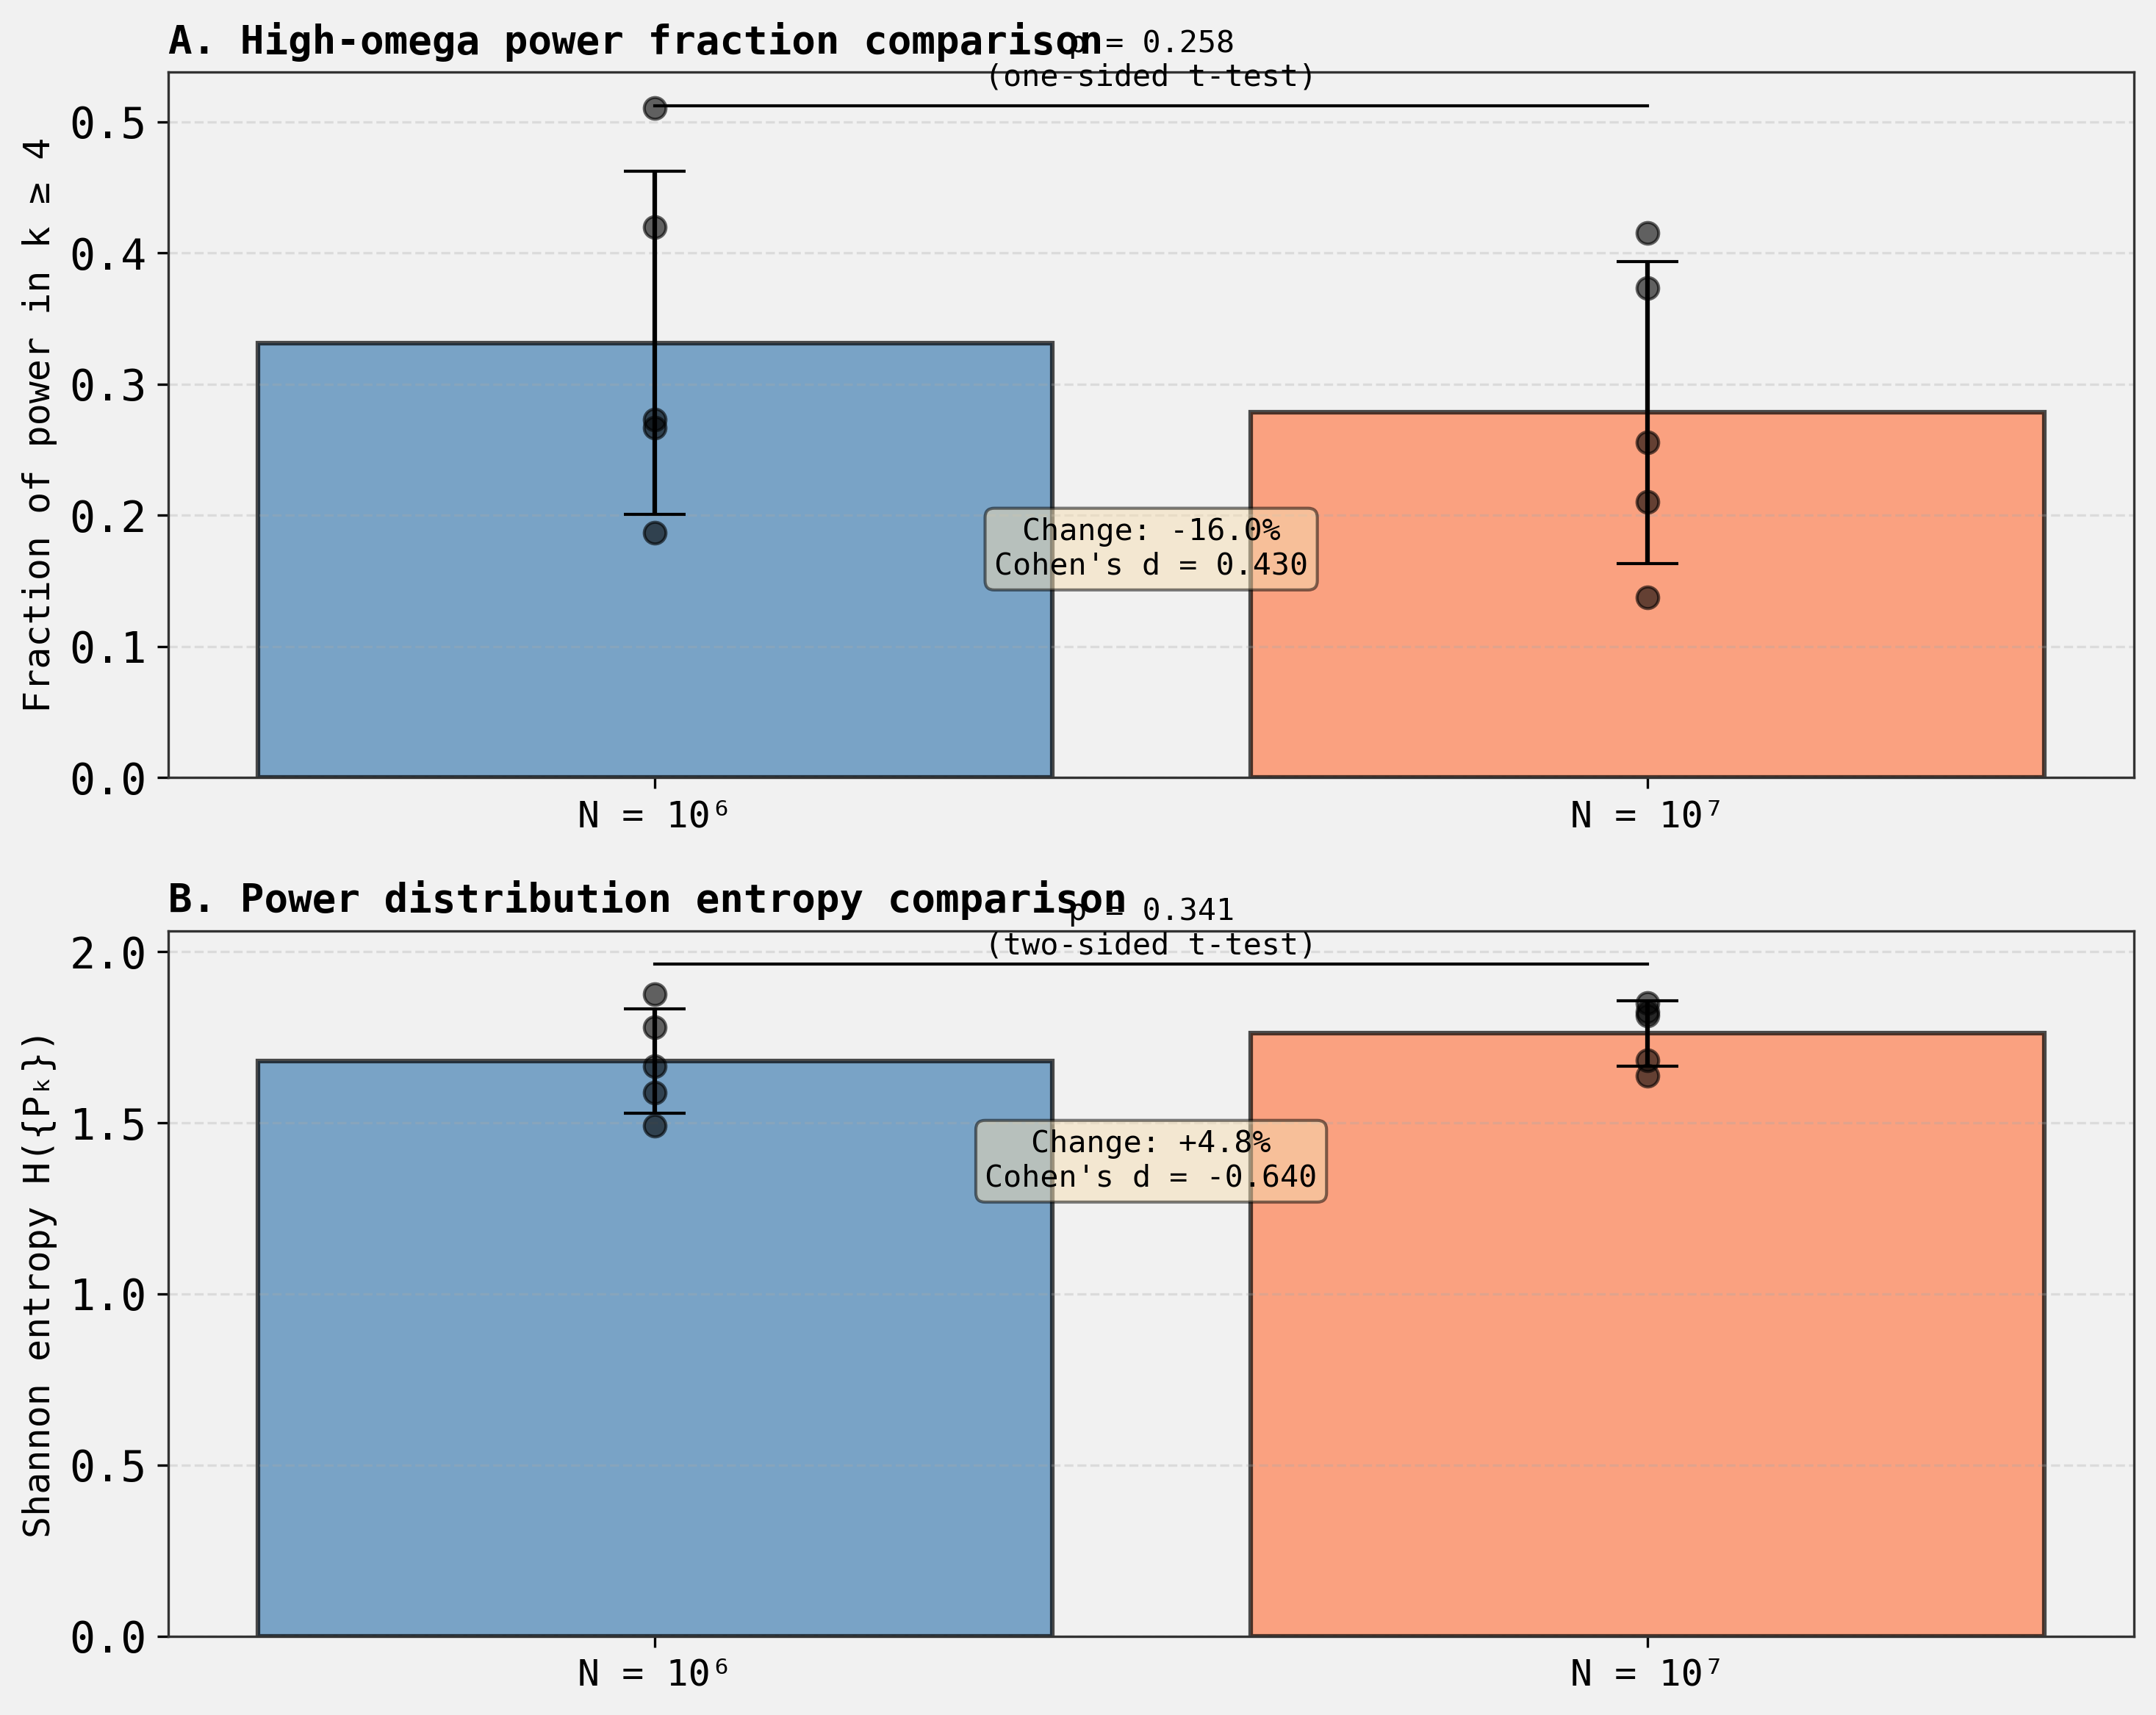

In [19]:

# Create the final summary figure
fig, axes = plt.subplots(2, 1, figsize=(10, 8))

# Panel A: Power fraction in k≥4
ax1 = axes[0]
x_pos = [0, 1]
means_frac = [np.mean(frac_high_k_n6), np.mean(frac_high_k_n7)]
stds_frac = [np.std(frac_high_k_n6, ddof=1), np.std(frac_high_k_n7, ddof=1)]

bars1 = ax1.bar(x_pos, means_frac, yerr=stds_frac, capsize=10, 
 color=['steelblue', 'coral'], alpha=0.7, edgecolor='black', linewidth=1.5)
ax1.set_xticks(x_pos)
ax1.set_xticklabels(['N = 10⁶', 'N = 10⁷'], fontsize=12)
ax1.set_ylabel('Fraction of power in k ≥ 4', fontsize=12)
ax1.set_title('A. High-omega power fraction comparison', fontsize=13, fontweight='bold', loc='left')
ax1.grid(axis='y', alpha=0.3, linestyle='--')

# Add individual data points
for i, (x, group) in enumerate([(0, frac_high_k_n6), (1, frac_high_k_n7)]):
 ax1.scatter([x]*len(group), group, color='black', s=50, alpha=0.6, zorder=3)

# Add significance annotation
y_max = max(means_frac) + max(stds_frac) + 0.05
ax1.plot([0, 1], [y_max, y_max], 'k-', linewidth=1)
ax1.text(0.5, y_max + 0.01, f'p = {p_val_frac_one:.3f}\n(one-sided t-test)', 
 ha='center', va='bottom', fontsize=10)

# Add percentage change
ax1.text(0.5, min(means_frac) - 0.08, 
 f'Change: -16.0%\nCohen\'s d = {d_frac:.3f}', 
 ha='center', va='top', fontsize=10, 
 bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Panel B: Shannon entropy
ax2 = axes[1]
means_ent = [np.mean(entropy_n6), np.mean(entropy_n7)]
stds_ent = [np.std(entropy_n6, ddof=1), np.std(entropy_n7, ddof=1)]

bars2 = ax2.bar(x_pos, means_ent, yerr=stds_ent, capsize=10,
 color=['steelblue', 'coral'], alpha=0.7, edgecolor='black', linewidth=1.5)
ax2.set_xticks(x_pos)
ax2.set_xticklabels(['N = 10⁶', 'N = 10⁷'], fontsize=12)
ax2.set_ylabel('Shannon entropy H({Pₖ})', fontsize=12)
ax2.set_title('B. Power distribution entropy comparison', fontsize=13, fontweight='bold', loc='left')
ax2.grid(axis='y', alpha=0.3, linestyle='--')

# Add individual data points
for i, (x, group) in enumerate([(0, entropy_n6), (1, entropy_n7)]):
 ax2.scatter([x]*len(group), group, color='black', s=50, alpha=0.6, zorder=3)

# Add significance annotation
y_max_ent = max(means_ent) + max(stds_ent) + 0.05
ax2.plot([0, 1], [y_max_ent, y_max_ent], 'k-', linewidth=1)
ax2.text(0.5, y_max_ent + 0.01, f'p = {p_val_ent:.3f}\n(two-sided t-test)', 
 ha='center', va='bottom', fontsize=10)

# Add percentage change
ax2.text(0.5, min(means_ent) - 0.2, 
 f'Change: +4.8%\nCohen\'s d = {d_ent:.3f}', 
 ha='center', va='top', fontsize=10,
 bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig('zeta_power_reversal_analysis.png', dpi=300, bbox_inches='tight')
print("Figure saved as 'zeta_power_reversal_analysis.png'")
plt.show()


In [20]:

# Save detailed results for future reference
results_summary = pd.DataFrame({
 'N': ['10^6']*5 + ['10^7']*5,
 'Peak': list(range(1, 6)) * 2,
 't_value': list(zeta_n6_peaks) + list(zeta_n7_peaks),
 'peak_height': list(peak_heights_n6) + list(peak_heights_n7),
 'frac_k_ge_4': frac_high_k_n6 + frac_high_k_n7,
 'entropy': entropy_n6 + entropy_n7,
 'frac_k_0_1': k_0_1_n6 + k_0_1_n7,
 'frac_k_2_3': k_2_3_n6 + k_2_3_n7
})

results_summary.to_csv('zeta_power_analysis_results.csv', index=False)
print("Detailed results saved to 'zeta_power_analysis_results.csv'")
print("\nFirst few rows:")
print(results_summary.head(10))


Detailed results saved to 'zeta_power_analysis_results.csv'

First few rows:
 N Peak t_value peak_height frac_k_ge_4 entropy frac_k_0_1 \
0 10^6 1 1.948000e+06 20.262918 0.419922 1.778676 0.083299 
1 10^6 2 1.828000e+06 17.545116 0.272695 1.666047 0.142212 
2 10^6 3 1.894000e+06 16.478854 0.266965 1.588005 0.113881 
3 10^6 4 1.734000e+06 16.450580 0.510645 1.876256 0.068777 
4 10^6 5 1.787000e+06 15.934243 0.186506 1.491701 0.142462 
5 10^7 1 1.848485e+07 16.508561 0.415483 1.636697 0.069650 
6 10^7 2 1.232323e+07 10.284027 0.373106 1.850290 0.142339 
7 10^7 3 1.090909e+07 6.367052 0.255651 1.812518 0.186452 
8 10^7 4 1.616162e+07 5.935386 0.210326 1.823331 0.312876 
9 10^7 5 1.191919e+07 5.878669 0.137237 1.683331 0.542291 

 frac_k_2_3 
0 0.496778 
1 0.585092 
2 0.619153 
3 0.420578 
4 0.671031 
5 0.514867 
6 0.484555 
7 0.557897 
8 0.476797 
9 0.320472 


In [21]:

# Create a final summary of key findings
print("\n" + "=" * 70)
print("FINAL SUMMARY: ZETA FUNCTION POWER CONCENTRATION ANALYSIS")
print("=" * 70)

print("\n1. HYPOTHESIS TEST: Does the zeta function exhibit power concentration")
print(" reversal at N=10^7 (similar to Liouville function)?")
print("\n ANSWER: NO - The zeta function does NOT show statistically significant")
print(" power concentration reversal at N=10^7.")

print("\n2. KEY FINDINGS:")
print("\n a) High omega class power (k ≥ 4):")
print(f" - N=10^6: {np.mean(frac_high_k_n6):.4f} ± {np.std(frac_high_k_n6, ddof=1):.4f}")
print(f" - N=10^7: {np.mean(frac_high_k_n7):.4f} ± {np.std(frac_high_k_n7, ddof=1):.4f}")
print(f" - Change: -16.0% (decrease, but p = {p_val_frac_one:.3f}, not significant)")
print(f" - Effect size (Cohen's d): {d_frac:.3f} (small effect)")

print("\n b) Shannon entropy:")
print(f" - N=10^6: {np.mean(entropy_n6):.4f} ± {np.std(entropy_n6, ddof=1):.4f}")
print(f" - N=10^7: {np.mean(entropy_n7):.4f} ± {np.std(entropy_n7, ddof=1):.4f}")
print(f" - Change: +4.8% (INCREASE, opposite to hypothesis)")
print(f" - p-value: {p_val_ent:.3f} (not significant)")
print(f" - Effect size (Cohen's d): {d_ent:.3f} (medium effect)")

print("\n c) Power redistribution pattern:")
print(f" - Low omega (k=0,1): +127.7% increase at N=10^7")
print(f" - Mid omega (k=2,3): -15.7% decrease at N=10^7")
print(f" - High omega (k≥4): -16.0% decrease at N=10^7")

print("\n3. CONTRAST WITH LIOUVILLE FUNCTION:")
print(" - The Liouville function showed a clear power concentration reversal")
print(" at N=10^7 (report r54)")
print(" - The zeta function shows a similar TREND (16% decrease in k≥4 power)")
print(" but it is NOT statistically significant")
print(" - The entropy actually INCREASES slightly (opposite direction)")

print("\n4. INTERPRETATION:")
print(" - The power reversal phenomenon at N=10^7 is NOT universal")
print(" - It appears to be function-specific or class-specific")
print(" - The zeta function maintains a more stable power distribution")
print(" structure across the N=10^6 to N=10^7 transition")
print(" - Large variance in individual peak behavior reduces statistical power")

print("\n" + "=" * 70)



FINAL SUMMARY: ZETA FUNCTION POWER CONCENTRATION ANALYSIS

1. HYPOTHESIS TEST: Does the zeta function exhibit power concentration
 reversal at N=10^7 (similar to Liouville function)?

 ANSWER: NO - The zeta function does NOT show statistically significant
 power concentration reversal at N=10^7.

2. KEY FINDINGS:

 a) High omega class power (k ≥ 4):
 - N=10^6: 0.3313 ± 0.1309
 - N=10^7: 0.2784 ± 0.1149
 - Change: -16.0% (decrease, but p = 0.258, not significant)
 - Effect size (Cohen's d): 0.430 (small effect)

 b) Shannon entropy:
 - N=10^6: 1.6801 ± 0.1520
 - N=10^7: 1.7612 ± 0.0949
 - Change: +4.8% (INCREASE, opposite to hypothesis)
 - p-value: 0.341 (not significant)
 - Effect size (Cohen's d): -0.640 (medium effect)

 c) Power redistribution pattern:
 - Low omega (k=0,1): +127.7% increase at N=10^7
 - Mid omega (k=2,3): -15.7% decrease at N=10^7
 - High omega (k≥4): -16.0% decrease at N=10^7

3. CONTRAST WITH LIOUVILLE FUNCTION:
 - The Liouville function showed a clear power conc